In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import avg, count, col, desc, sum

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Project 2 - Flights 1987") \
    .getOrCreate()

# Load the dataset
flights_df = spark.read.csv("../inputs/1987_flights.csv", header=True, inferSchema=True)

# Question 2:Show row count of dataset
row_count = flights_df.count()
print(f"Row count of dataset: {row_count}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/20 11:12:16 WARN Utils: Your hostname, Codys-MacBook-Neo.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.9 instead (on interface en0)
26/06/20 11:12:16 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/20 11:12:16 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Row count of dataset: 1048575


In [2]:
# Show first part of dataset
flights_df.show(5)

+----+-----+----------+---------+-------+----------+-------+----------+-------------+---------+-------+-----------------+--------------+-------+--------+--------+------+----+--------+------+-------+---------+----------------+--------+------------+------------+--------+-------------+-----------------+
|Year|Month|DayofMonth|DayOfWeek|DepTime|CRSDepTime|ArrTime|CRSArrTime|UniqueCarrier|FlightNum|TailNum|ActualElapsedTime|CRSElapsedTime|AirTime|ArrDelay|DepDelay|Origin|Dest|Distance|TaxiIn|TaxiOut|Cancelled|CancellationCode|Diverted|CarrierDelay|WeatherDelay|NASDelay|SecurityDelay|LateAircraftDelay|
+----+-----+----------+---------+-------+----------+-------+----------+-------------+---------+-------+-----------------+--------------+-------+--------+--------+------+----+--------+------+-------+---------+----------------+--------+------------+------------+--------+-------------+-----------------+
|1987|   10|        14|        3|    741|       730|    912|       849|           PS|     1451

26/06/20 11:12:22 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [ ]:
# Question 3: Top 5 destination airports with longest departure delays in December
top5_delays = (
    flights_df
    .filter(flights_df.Month == 12)
    .filter(col("DepDelay") != "NA")
    .groupBy("Dest")
    .agg(avg("DepDelay").alias("AvgDepDelay"))
    .orderBy(desc("AvgDepDelay"))
    .limit(5)
)
top5_delays.show()


+----+------------------+
|Dest|       AvgDepDelay|
+----+------------------+
| ACV|              29.9|
| RDD|29.117117117117118|
| YKM| 27.74074074074074|
| HNL|25.615658362989326|
| BOI|25.210526315789473|
+----+------------------+



In [4]:
monthly_delays = (
    flights_df
    .filter(
        (col("DepDelay").isNotNull()) &
        (col("DepDelay") != "NA") &
        (col("DepDelay") != "")
    )
    .withColumn("DepDelay", col("DepDelay").cast("double"))
    .groupBy("Month")
    .agg(sum("DepDelay").alias("TotalDepDelay"))
    .orderBy("Month")
)
monthly_delays.show()

+-----+-------------+
|Month|TotalDepDelay|
+-----+-------------+
|   10|    2253727.0|
|   11|    2976603.0|
|   12|    2098492.0|
+-----+-------------+



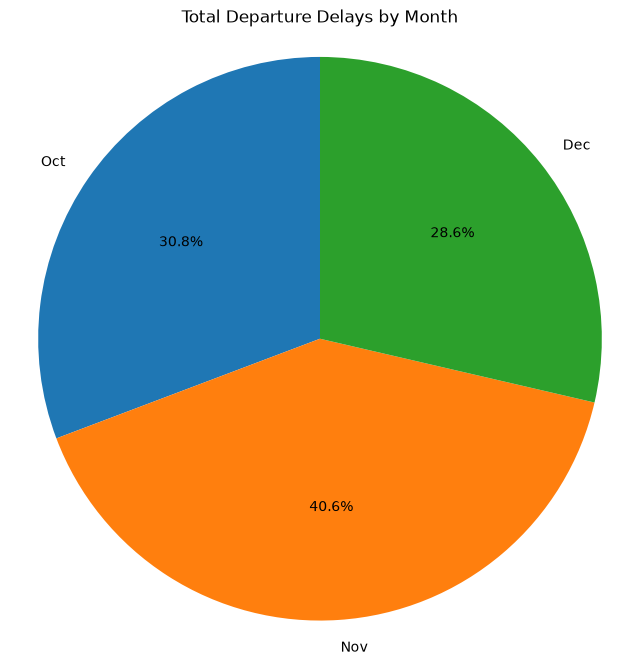

In [ ]:
# Question 4: Creating pie chart for total departure delays by month
import matplotlib.pyplot as plt
import pandas as pd

delays_df = monthly_delays.toPandas()

month_map = {
    '10': 'Oct', '11': 'Nov', '12': 'Dec'
}

delays_df['Month_Abbr'] = delays_df['Month'].astype(str).map(month_map)

plt.figure(figsize=(8, 8))
plt.pie(
    delays_df["TotalDepDelay"],
    labels=delays_df["Month_Abbr"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Total Departure Delays by Month")
plt.axis("equal")
plt.show()

In [ ]:
# Question 5: Using SQL to find total departure delays by day of the week
flights_df.createOrReplaceTempView("flights")

day_delays = spark.sql("""
    SELECT DayofWeek,
        SUM(CAST(DepDelay AS DOUBLE)) AS TotalDelay
    FROM flights
    WHERE DepDelay != 'NA'
        AND CAST(DepDelay AS DOUBLE) > 0
    GROUP BY DayofWeek
    ORDER BY DayofWeek
""")
day_delays.show()

+---------+----------+
|DayofWeek|TotalDelay|
+---------+----------+
|        1| 1087330.0|
|        2| 1123137.0|
|        3| 1234626.0|
|        4| 1225376.0|
|        5| 1062223.0|
|        6|  752415.0|
|        7| 1200996.0|
+---------+----------+



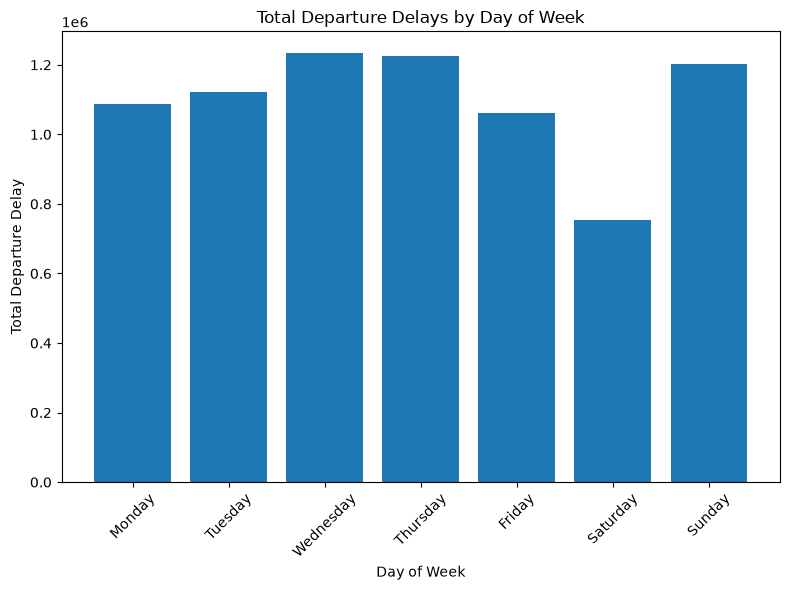

26/06/20 12:50:31 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 308709 ms exceeds timeout 120000 ms
26/06/20 12:50:31 WARN SparkContext: Killing executors is not supported by current scheduler.
26/06/20 12:50:32 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [ ]:
# Create a bar chart for total departure delays by day of the week to complete question 5
day_delays_df = day_delays.toPandas()

day_map = {
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday',
    7: 'Sunday'
}

day_delays_df['DayOfWeek'] = day_delays_df['DayofWeek'].map(day_map)
plt.figure(figsize=(8, 6))
plt.bar(day_delays_df["DayOfWeek"], day_delays_df["TotalDelay"])
plt.xlabel("Day of Week")
plt.ylabel("Total Departure Delay")
plt.title("Total Departure Delays by Day of Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()